## Guardrails

Guardrails help you build safe, compliant AI applications by validating and filtering content at key points in your agent's execution.

They are implemented as middleware that intercepts execution:

- Before the agent starts (input guardrails)
- After it completes (output guardrails)
- Around model and tool calls


📚 Topics Covered

- What are Guardrails & Why do they matter?
- Two approaches: Deterministic vs Model-based
- Built-in: PII Detection Middleware
- Built-in: Human-in-the-Loop Middleware
- Custom: Before-Agent Guardrail (input filtering)
- Custom: After-Agent Guardrail (output safety)
- Layered / Combined Guardrails
- Real-World Use Case: Healthcare Chatbot


### Common Use Cases

| Use Case | Example |
|---|---|
| PII Leakage Prevention | Redact emails or credit card numbers before logging |
| Prompt Injection Blocking | Detect and block adversarial or malicious inputs |
| Harmful Content Filtering | Identify and block dangerous requests |
| Business Rule Enforcement | Require approval before performing financial operations |
| Output Quality Validation | Ensure the response meets predefined safety or quality standards |

### Guardrails Approaches 

#### Deterministic Guardrails

- **Rule-based:** Uses regex, keyword matching, and explicit checks.
- **Advantages:** Fast, predictable, and cost-effective.
- **Limitations:** May miss nuanced or context-dependent violations.

#### Model-Based Guardrails

- **Model-based:** Uses LLMs or classifiers for semantic understanding.
- **Advantages:** Can detect subtle, complex, or nuanced issues.
- **Limitations:** Generally slower and more expensive.

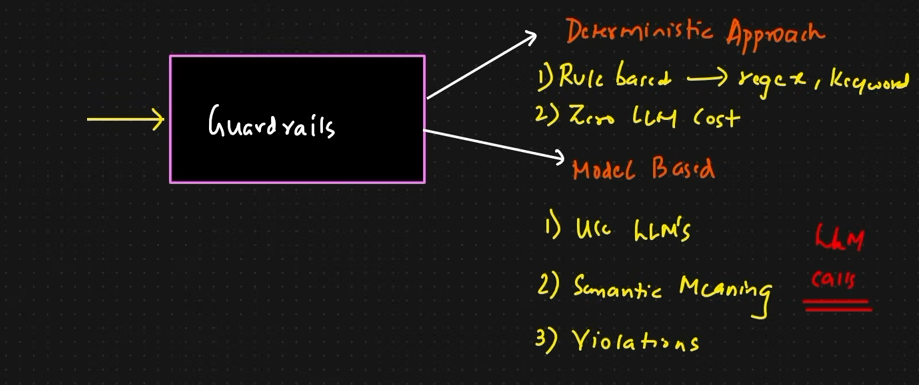

In [1]:
import os 
from getpass import getpass
from dotenv import load_dotenv
load_dotenv()

os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")

In [2]:
# Illustration of two approaches 
import re 

# Deterministic Approach 
def deterministic_guardrail(text: str)  -> bool: 
    """Returns True if content is blocked"""
    banned_keywords = ["hack", "exploit", "malware", "bomb"]
    return any(kw in text.lower() for kw in banned_keywords)

test_inputs = [
    "How do I hack into a database?", 
    "What is the capital of France?", 
    "Explain how malware spreads"
]


print("=====Deterministic Guardrail Demo=====")
for inp in test_inputs: 
    blocked = deterministic_guardrail(inp)
    status = "🚫 BLOCKED" if blocked else "✅ ALLOWED"
    print(f"{status}: {inp}")

=====Deterministic Guardrail Demo=====
🚫 BLOCKED: How do I hack into a database?
✅ ALLOWED: What is the capital of France?
🚫 BLOCKED: Explain how malware spreads


In [7]:
from langchain_groq import ChatGroq

# model based approach 
def model_based_guardrail(text: str) -> str: 
    """Uses an LLM to evaluate ocntent safety, returns SAFE or UNSAFE """
    model = ChatGroq(model = "openai/gpt-oss-120b", temperature=0)
    prompt = f"""Is the following user input safe to process? Reply iwht only 'SAFE' or 'UNSAFE'. \nInput: {text}"""

    result = model.invoke([{"role": "user", "content": prompt}])
    return result.content.strip()

print("====Model Based Guardrail Demo====")
for inp in test_inputs: 
    verdict = model_based_guardrail(inp)
    status = "🚫 UNSAFE" if "UNSAFE" in verdict else "✅ SAFE"
    print(f"{status}: {inp}")

====Model Based Guardrail Demo====
🚫 UNSAFE: How do I hack into a database?
✅ SAFE: What is the capital of France?
🚫 UNSAFE: Explain how malware spreads
